## Data Evaluation

In [1]:
import sys
from pathlib import Path

# Add repo root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import Normalize

import utils
from settings import *


In [2]:
# Load metrics data from csv
df = pd.read_csv(METRICS_CSV)
print(f"Loaded: {METRICS_CSV}")

# Add computed metric column, resave file
df[COMPUTED_METRIC_COL] = COMPUTED_METRIC_FN(df)
df["sample_id"] = df["sample_id"].astype(str).str.zfill(12)
df.to_csv(METRICS_CSV, index=False)
df["sample_id"] = df["sample_id"].astype(int)

na_mask = df[METRIC_COLS].notna().all(axis=1)
print(f"Dropped {(~na_mask).sum()} rows")
df = df[na_mask]

# Cast parameter columns to categorical so that plots order them correctly
for col in ["t_start", "t_end", "t_delta"]:
    df[col] = pd.Categorical(df[col], categories=sorted(df[col].unique()), ordered=True)

print(f"Shape: {df.shape}")
df.describe()

Loaded: /data/home/mirick/ChordEdit/models/classification/data/id_to_metrics_sdturbo.csv
Dropped 0 rows
Shape: (84700, 9)


,sample_id,psnr,clip_target_similarity,combined_score,combined_score_p0.5_c_0.5,naive_pareto_score
count,8.470000e+04,84700.000000,84700.000000,84700.000000,84700.000000,84700.000000
mean,4.025714e+11,21.025530,23.974392,0.487278,0.487278,1.306499
std,3.248350e+11,5.354163,4.119788,0.084191,0.084191,3.111577
min,0.000000e+00,6.223442,6.510458,0.161138,0.161138,0.000000
25%,1.140000e+11,17.073606,21.323045,0.429891,0.429891,0.000000
50%,3.215000e+11,20.762713,24.095054,0.484614,0.484614,0.000000
75%,7.212500e+11,24.600626,26.832104,0.541954,0.541954,0.000000
max,9.240000e+11,40.323571,38.822430,0.856489,0.856489,21.004289


### 1  Load & Inspect

### 2  Metric Distributions

Before slicing by parameters, let's see the marginal distribution of each metric.

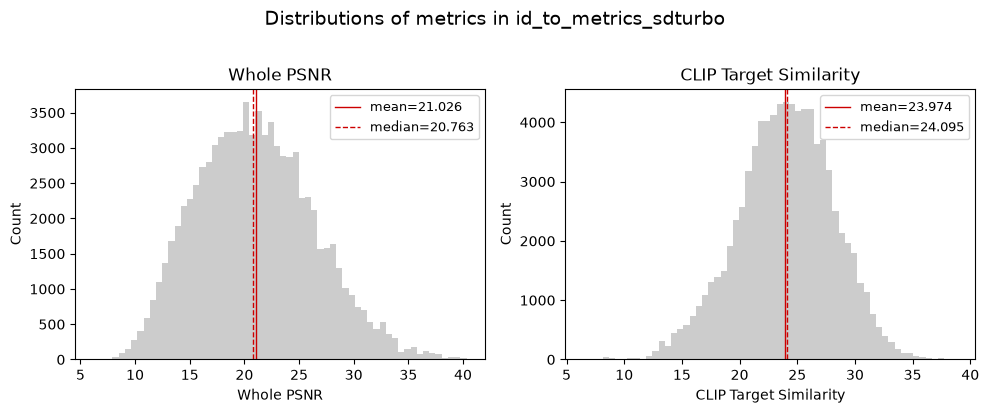

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, m in zip(axes, METRIC_COLS[:2]):
    ax.hist(df[m], color="silver", bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="#cc0000", lw=1.0, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="#cc0000", lw=1.0, linestyle="--", label=f"median={df[m].median():.3f}")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle(f"Distributions of metrics in {METRICS_CSV.stem}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, m in zip(axes, METRIC_COLS):
    ax.hist(df[m], color="silver", bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="#cc0000", lw=1.0, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="#cc0000", lw=1.0, linestyle="--", label=f"median={df[m].median():.3f}")
    # ax.set_yscale("log" if m == "naive_pareto_score" else "linear")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle(f"Distributions of metrics in {METRICS_CSV.stem}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3  Effect of `t_start` and `t_end` on Metrics

We first split the data by `t_delta` (0.0 vs 0.15) because that parameter shifts the absolute
level of every metric.  Within each `t_delta` slice we look at how the marginal means of
`t_start` and `t_end` vary.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey="col")

t_delta_vals = sorted(df["t_delta"].cat.categories)
colors = {"t_start": "#1f77b4", "t_end": "#ff7f0e"}

for row_idx, td in enumerate(t_delta_vals):
    sub = df[df["t_delta"] == td]
    for col_idx, m in enumerate(METRIC_COLS):
        ax = axes[row_idx, col_idx]
        for param, label in [("t_start", "t_start"), ("t_end", "t_end")]:
            grp = sub.groupby(param, observed=True)[m].agg(["mean", "sem"])
            x = grp.index.astype(float)
            ax.errorbar(
                x, grp["mean"], yerr=1.96 * grp["sem"],
                marker="o", label=param, color=colors[param],
                capsize=4, linewidth=2,
            )
        ax.set_xlabel("Parameter value")
        ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
        ax.set_title(f"{METRIC_LABELS[m]}  |  t_delta={td}")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))
        if col_idx == 2:
            ax.legend(fontsize=9)

fig.suptitle("Marginal Mean ± 95% CI by t_start / t_end", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1  Box-plots: Full Distribution by `t_start` and `t_end`

Means can hide skew.  Box-plots show the spread across the 700 samples per level.

In [ ]:
for td in t_delta_vals:
    sub = df[df["t_delta"] == td]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="col")
    for col_idx, m in enumerate(METRIC_COLS):
        for row_idx, param in enumerate(["t_start", "t_end"]):
            ax = axes[row_idx, col_idx]
            order = [str(v) for v in sorted(sub[param].cat.categories)]
            sns.boxplot(
                data=sub, x=param, y=m, order=order,
                ax=ax, color=colors[param], fliersize=1, linewidth=0.8,
            )
            ax.set_xlabel(param)
            ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
            ax.set_title(f"{METRIC_LABELS[m]}" if row_idx == 0 else "")
    fig.suptitle(f"Distributions by t_start / t_end  (t_delta={td})", fontsize=13)
    plt.tight_layout()
    plt.show()

### 4  Joint Effect: `t_start` × `t_end` Heatmaps

Each cell shows the mean metric value across the 700 samples at that `(t_start, t_end)` setting.
We separate the two `t_delta` values to compare their landscapes.

In [ ]:
for m in METRIC_COLS:
    n_td = len(t_delta_vals)
    fig, axes = plt.subplots(1, n_td, figsize=(7 * n_td, 5))
    if n_td == 1:
        axes = [axes]

    # Build all pivots first so we can normalise across all t_delta panels
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_start")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for ax, td in zip(axes, t_delta_vals):
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)
        sns.heatmap(
            norm_pivot, ax=ax, annot=True, fmt=".3f",
            cmap="viridis", vmin=0, vmax=1,
            linewidths=0.4, linecolor="#e0e0e0",
            cbar_kws={"label": f"Normalized {METRIC_LABELS[m]}"},
            annot_kws={"size": 8},
        )
        ax.set_title(f"$\\delta$ = {td}")
        ax.set_xlabel("t_start")
        ax.set_ylabel("t_end")
        ax.invert_yaxis()
    fig.suptitle(f"Normalized mean {m} in {METRICS_CSV.stem}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

for m in METRIC_COLS:
    fig = plt.figure()

    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for i, td in enumerate(t_delta_vals):
        ax = fig.add_subplot(1, 1, i + 1, projection="3d")
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)

        xs = norm_pivot.index.values    # t_start
        ys = norm_pivot.columns.values  # t_end
        n_x, n_y = len(xs), len(ys)

        xpos = np.repeat(np.arange(n_x), n_y)
        ypos = np.tile(np.arange(n_y), n_x)
        zpos = np.zeros(n_x * n_y)
        dz   = norm_pivot.values.ravel()

        bar_colors = plt.cm.viridis(dz)
        ax.bar3d(xpos, ypos, zpos, dx=0.65, dy=0.65, dz=dz,
                 color=bar_colors, shade=True, alpha=0.4)

        ax.set_xticks(np.arange(n_x) + 0.325)
        ax.set_xticklabels([f"{v:.1f}" for v in xs], fontsize=8)
        ax.set_yticks(np.arange(n_y) + 0.325)
        ax.set_yticklabels([f"{v:.1f}" for v in ys], fontsize=8)
        ax.set_xlabel("t_start", labelpad=8)
        ax.set_ylabel("t_end",   labelpad=8)
        # ax.set_zlabel(f"Normalized {METRIC_LABELS[m]}", labelpad=8)
        ax.set_zlim(0, 1)
        ax.set_title(f"{METRIC_LABELS[m]} with $\\delta$={td:.2f}", y=1.0, fontsize=10)
        ax.view_init(elev=30, azim=225)  # isometric-style viewpoint

    mappable = plt.cm.ScalarMappable(cmap="viridis",
                                     norm=plt.Normalize(vmin=0, vmax=1))
    mappable.set_array([])

    fig.suptitle(
        f"Normalized 3d graph of mean {METRIC_LABELS[m].lower()} \n in {METRICS_CSV.stem}",
        fontsize=14, y=1.1,
    )
    fig.subplots_adjust(top=1.0)
    plt.show()

### 5  Interaction: Does `t_delta` Change the Landscape?

Plot the *difference* between the t_delta=0.15 heatmap and the t_delta=0.0 heatmap for
each metric.  Positive values (warm colours) mean t_delta=0.15 is better at that cell.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, METRIC_COLS):
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivots[td] = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean().unstack("t_end")
        )
    diff = pivots[0.15] - pivots[0.0]
    diff.index   = diff.index.astype(float)
    diff.columns = diff.columns.astype(float)
    lim = np.abs(diff.values).max()
    sns.heatmap(
        diff, ax=ax, annot=True, fmt="+.3f",
        cmap="RdYlGn", center=0, vmin=-lim, vmax=lim,
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": "Δ (t_delta=0.15 − 0.00)"},
    )
    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")
    ax.invert_yaxis()
fig.suptitle("Δ Metric: t_delta=0.15 minus t_delta=0.00", fontsize=13)
plt.tight_layout()
plt.show()

### 6  Metric Correlations

PSNR and CLIP similarity are independent signals; the combined score is their normalised
average.  A pairplot reveals how correlated they are in practice.

In [ ]:
sample = df.sample(n=3000, random_state=42)
g = sns.pairplot(
    sample[METRIC_COLS + ["t_delta"]],
    hue="t_delta",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    corner=True,
)
g.fig.suptitle("Pairwise Metric Correlations (3 000-sample subset)", y=1.02, fontsize=13)
plt.show()

print("Pearson correlation matrix:")
df[METRIC_COLS].corr().round(3)

### 7  Best Parameter Settings

For each metric we rank every `(t_start, t_end, t_delta)` triple by its **mean** value and
report the top-5.  We also report the 90th-percentile mean to favour settings that are
reliably good, not just occasionally high.

> **Note:** The training pipeline filters to `t_delta == 0.0` before selecting the best
> row per sample, so the analysis below includes a dedicated view of the `t_delta == 0.0`
> landscape.

In [ ]:
stats = (
    df.groupby(["t_start", "t_end", "t_delta"], observed=True)[METRIC_COLS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

print(f"=== Top-5 by mean {COMPUTED_METRIC_LABEL} (all t_delta) ===")
display(
    stats.nlargest(5, f"{COMPUTED_METRIC_COL}_mean")[
        ["t_start", "t_end", "t_delta",
         f"{COMPUTED_METRIC_COL}_mean", f"{COMPUTED_METRIC_COL}_std",
         "psnr_mean", "clip_similarity_target_image_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean PSNR (all t_delta) ===")
display(
    stats.nlargest(5, "psnr_mean")[
        ["t_start", "t_end", "t_delta",
         "psnr_mean", "psnr_std", f"{COMPUTED_METRIC_COL}_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean CLIP similarity (all t_delta) ===")
display(
    stats.nlargest(5, "clip_similarity_target_image_mean")[
        ["t_start", "t_end", "t_delta",
         "clip_similarity_target_image_mean",
         "clip_similarity_target_image_std", f"{COMPUTED_METRIC_COL}_mean"]
    ].round(4)
)

### 7.1  Best Settings at `t_delta == 0.0`

The training pipeline uses only the `t_delta == 0` slice, so the classifier needs to
predict the best `(t_start, t_end)` within that slice.

In [ ]:
stats0 = (
    df[df["t_delta"] == 0.0]
    .groupby(["t_start", "t_end"], observed=True)[METRIC_COLS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats0.columns = ["_".join(c) for c in stats0.columns]
stats0 = stats0.reset_index()

for m in METRIC_COLS:
    col = f"{m}_mean"
    top = stats0.nlargest(5, col).reset_index(drop=True)
    top.index += 1
    print(f"\n=== Top-5 (t_delta=0) by mean {METRIC_LABELS[m]} ===")
    display(top[["t_start", "t_end", col, f"{m}_std"]].round(4))

### 7.2  Visual Summary: Ranked Cells (t_delta = 0)

Each heatmap is re-drawn with the **top-3 cells** annotated with their rank.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sub0 = df[df["t_delta"] == 0.0]

for ax, m in zip(axes, METRIC_COLS):
    pivot = (
        sub0.groupby(["t_start", "t_end"], observed=True)[m]
        .mean().unstack("t_end")
    )
    pivot.index   = pivot.index.astype(float)
    pivot.columns = pivot.columns.astype(float)

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f",
        cmap="YlGn",
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": METRIC_LABELS[m]},
    )
    ax.invert_yaxis()

    # Annotate top-3 cells with rank badges
    flat = pivot.stack().sort_values(ascending=False)
    rows_list = list(pivot.index)
    cols_list = list(pivot.columns)
    for rank, (idx, _) in enumerate(flat.head(3).items(), start=1):
        r, c = idx
        ri = rows_list.index(r)
        ci = cols_list.index(c)
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor="red", lw=2.5))
        ax.text(ci + 0.05, ri + 0.15, f"#{rank}", color="red",
                fontsize=10, fontweight="bold")

    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")

fig.suptitle("Mean Metric Heatmaps (t_delta=0)  — top-3 cells outlined in red", fontsize=13)
plt.tight_layout()
plt.show()

### 8  Summary: Best Parameters per Metric

The table below consolidates the single best `(t_start, t_end)` for each metric
within the `t_delta == 0` slice (which is what the classifier is trained to predict).

In [ ]:
rows = []
for m in METRIC_COLS:
    col = f"{m}_mean"
    best = stats0.loc[stats0[col].idxmax()]
    rows.append({
        "Metric": METRIC_LABELS[m],
        "Best t_start": float(best["t_start"]),
        "Best t_end":   float(best["t_end"]),
        "Mean value":   round(best[col], 4),
        "Std dev":      round(best[f"{m}_std"], 4),
    })

summary = pd.DataFrame(rows).set_index("Metric")
display(summary)

### 9  Top Samples by `TARGET_COLUMN`

Rows with the highest individual `agreement_score` values, with their source/target prompts and diffusion parameters.

In [ ]:
from models.classification.settings import STRINGS_CSV

strings = pd.read_csv(STRINGS_CSV, dtype={"id": str})
strings["sample_id"] = strings["id"].astype(int)

merged = df.merge(strings[["sample_id", "source_prompt", "target_prompt"]], on="sample_id", how="left")

cols = ["sample_id", "source_prompt", "target_prompt", "t_start", "t_end", COMPUTED_METRIC_COL]
top_samples = (
    merged.nlargest(20, COMPUTED_METRIC_COL)[cols]
    .reset_index(drop=True)
)
top_samples.index += 1

pd.set_option("display.max_colwidth", 120)
display(top_samples)

In [ ]:
# Only consider rows with valid PSNR and CLIP scores
valid = df.dropna(subset=["psnr", "clip_similarity_target_image"])

# Mask for rows at the default parameter pair
default_mask = (
    (valid["t_start"].astype(float) == PAPER_T_START) &
    (valid["t_end"].astype(float) == PAPER_T_END)
)
df_default = valid[default_mask]

# Best per sample_id, row with the highest COMPUTED_METRIC_COL for each image
best_idx = valid.groupby("sample_id")[COMPUTED_METRIC_COL].idxmax()
df_best = valid.loc[best_idx]

# --- Descriptive stats side-by-side ---
comparison = pd.DataFrame({
    f"default ({PAPER_T_START}, {PAPER_T_END})": df_default[METRIC_COLS].mean(),
    "per-sample best": df_best[METRIC_COLS].mean(),
}).T
comparison.columns = METRIC_COLS
display(comparison.round(4))

# --- Metric distribution comparison ---
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(5 * len(METRIC_COLS), 4))
colors_grp = {"default": "#5b9bd5", "best": "#ed7d31"}

for ax, m in zip(axes, METRIC_COLS):
    for label, sub, clr in [
        (f"default ({PAPER_T_START}, {PAPER_T_END})", df_default, colors_grp["default"]),
        ("per-sample best", df_best, colors_grp["best"]),
    ]:
        ax.hist(sub[m], bins=40, alpha=0.55, color=clr, label=label, edgecolor="none", density=True)
        ax.axvline(sub[m].mean(), color=clr, lw=2, linestyle="--")

    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Density")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=8)

fig.suptitle(
    f"Metric distributions: default params vs per-sample best {COMPUTED_METRIC_LABEL}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# --- t_start / t_end distribution of per-sample best rows ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, param in zip(axes, ["t_start", "t_end"]):
    counts = df_best[param].astype(float).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#ed7d31", edgecolor="none")
    ax.set_xlabel(param)
    ax.set_ylabel("Count (samples where this value is best)")
    ax.set_title(f"Distribution of best {param}")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    f"t_start / t_end values at per-sample best {COMPUTED_METRIC_LABEL}",
    fontsize=13,
)
plt.tight_layout()
plt.show()


### 10  Naive Pareto Score Analysis

For each `sample_id` group the **baseline** row is `(t_start=PAPER_T_START, t_end=PAPER_T_END)`.
A row **improves** if both ΔPSNR > 0 and ΔCLIP > 0 vs that baseline; its score is
`1 + ΔPSNR + ΔCLIP`, otherwise `0` (including the baseline itself).

Computed fresh via `utils.compute_naive_pareto_score` regardless of `COMPUTED_METRIC_FN`.

Total rows      : 84,700
Baseline rows   : 700  (score=1, one per sample_id)
Improving rows  : 16,546  (19.5%,  score = 1+ΔPSNR+ΔCLIP)
Non-improving   : 67,454  (79.6%,  score=0)

Improving score — min:1.024  mean:6.646  max:21.004


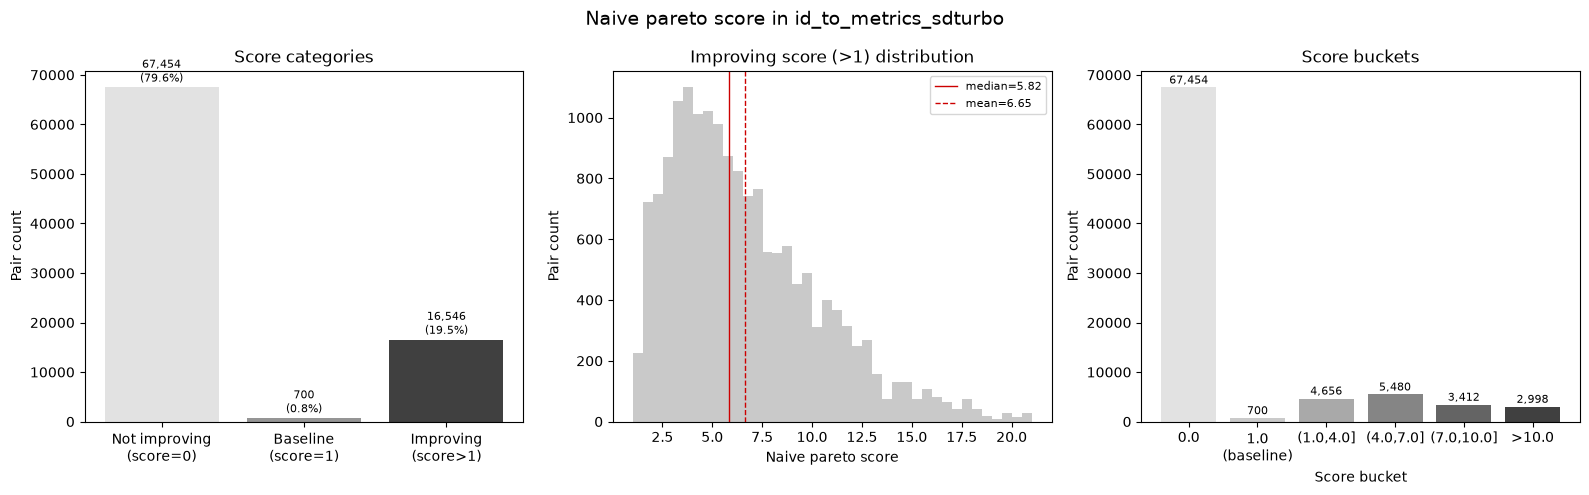

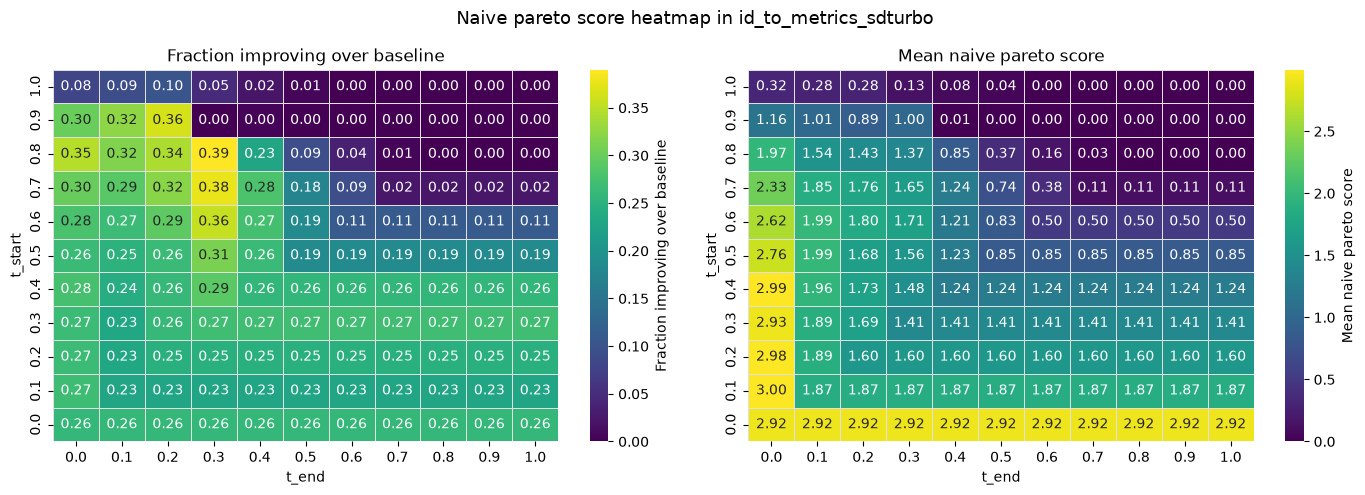

ValueError: 
A pair $(t^*, t^{**})$ has a `naive_pareto_score` of $0$ if PSNR or CLIP-Edited are worse than an image generated with the paper's baseline $(0.9, 0.3)$, 1 if PSNR and CLIP-Edited are equal, and $1+\Delta\text{{PSNR}}+\Delta\text{{CLIP-Edited}}$ if PSNR and CLIP-Edited are greater.
                                                                                                                                                                                                   ^
ParseException: Expected end of text, found '$'  (at char 195), (line:1, col:196)

<Figure size 1400x600 with 2 Axes>

In [46]:
from matplotlib.patches import Patch

# Always recompute directly — independent of COMPUTED_METRIC_FN
_nps = compute_naive_pareto_score(df)
df["_nps"] = _nps

# Isolate pairs that are Pareto improvements
improving     = df["_nps"] > 1  # >1 = genuinely better; ==1 = baseline row itself
baseline_rows = (
    np.isclose(df["t_start"].astype(float), PAPER_T_START) &
    np.isclose(df["t_end"].astype(float),   PAPER_T_END)
)

"""
Report general statistics about the data
"""

n_total     = len(df)
n_improving = int(improving.sum())
n_baseline  = int(baseline_rows.sum())
n_neither   = n_total - n_improving - n_baseline

print(f"Total rows      : {n_total:,}")
print(f"Baseline rows   : {n_baseline:,}  (score=1, one per sample_id)")
print(f"Improving rows  : {n_improving:,}  ({100*n_improving/n_total:.1f}%,  score = 1+ΔPSNR+ΔCLIP)")
print(f"Non-improving   : {n_neither:,}  ({100*n_neither/n_total:.1f}%,  score=0)")
imp_scores = df.loc[improving, "_nps"]
if n_improving:
    print(f"\nImproving score — min:{imp_scores.min():.3f}  mean:{imp_scores.mean():.3f}  max:{imp_scores.max():.3f}")


"""
Category counts, histogram, score buckets
"""

cmap = plt.get_cmap("Greys")

bin_edges = [-0.001, 0.001, 1.001, 4.0, 7.0, 10.0, float("inf")]
bin_labels = ["0.0", "1.0\n(baseline)", "(1.0,4.0]", "(4.0,7.0]", "(7.0,10.0]", ">10.0"]
bkt_colors = [cmap(x) for x in np.linspace(0.2, 0.8, 6)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
cat_labels = ["Not improving\n(score=0)", "Baseline\n(score=1)", "Improving\n(score>1)"]
cat_counts  = [n_neither, n_baseline, n_improving]
bars = ax.bar(cat_labels, cat_counts, color=[cmap(x) for x in np.linspace(0.2, 0.8, 3)], edgecolor="none")
for bar, cnt in zip(bars, cat_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_total*0.005,
            f"{cnt:,}\n({100*cnt/n_total:.1f}%)", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Pair count")
ax.set_title("Score categories")

ax = axes[1]
if n_improving:
    ax.hist(imp_scores, bins=40, color="silver", edgecolor="none", alpha=0.85)
    ax.axvline(imp_scores.median(), color="#cc0000", lw=1.0, linestyle="-",label=f"median={imp_scores.median():.2f}")
    ax.axvline(imp_scores.mean(), color="#cc0000", lw=1.0, linestyle="--",label=f"mean={imp_scores.mean():.2f}")
    ax.set_xlabel("Naive pareto score")
    ax.set_ylabel("Pair count")
    ax.legend(fontsize=8)
ax.set_title("Improving score (>1) distribution")

ax = axes[2]
bucket_counts = pd.cut(df["_nps"], bins=bin_edges, labels=bin_labels).value_counts().reindex(bin_labels)
b = ax.bar(bin_labels, bucket_counts.values, color=bkt_colors, edgecolor="none")
for bar, cnt in zip(b, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_total*0.003,
            f"{cnt:,}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Score bucket")
ax.set_ylabel("Pair count")
ax.set_title("Score buckets")

fig.suptitle(f"Naive pareto score in {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()

"""
Heatmaps
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_frac = df.groupby(["t_start", "t_end"], observed=True).apply(
    lambda g: (g["_nps"] > 1).mean()
).unstack("t_end")
pivot_mean = df.groupby(["t_start", "t_end"], observed=True)["_nps"].mean().unstack("t_end")

for ax, pivot, title, fmt in [
    (axes[0], pivot_frac, "Fraction improving over baseline", ".2f"),
    (axes[1], pivot_mean, "Mean naive pareto score",          ".2f"),
]:
    pivot.index   = pivot.index.astype(float)
    pivot.columns = pivot.columns.astype(float)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt, cmap="viridis",
                linewidths=0.4, linecolor="#e0e0e0", cbar_kws={"label": title})
    ax.set_title(title)
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")
    ax.invert_yaxis()

fig.suptitle(f"Naive pareto score heatmap in {METRICS_CSV.stem}", fontsize=13)
plt.tight_layout()
plt.show()

"""
Scatter Plots
"""

# Compute per-sample PSNR/CLIP deltas
_base = (
    df[baseline_rows][["sample_id", "psnr", "clip_target_similarity"]]
    .rename(columns={"psnr": "_b_psnr", "clip_target_similarity": "_b_clip"})
)
_sc = df.merge(_base, on="sample_id", how="inner")
_sc["_dpsnr"] = _sc["psnr"] - _sc["_b_psnr"]
_sc["_dclip"]  = _sc["clip_target_similarity"] - _sc["_b_clip"]
_sc = _sc[~(np.isclose(_sc["_dpsnr"], 0) & np.isclose(_sc["_dclip"], 0))]

# Best row per sample_id: highest naive pareto score, ties broken by order
_sc_best = _sc.loc[_sc.groupby("sample_id")["_nps"].idxmax()]

def _scatter_plot(ax, data, title, sample_size=None, color_imp="#1f77b4", color_no="#aec7e8"):
    if sample_size:
        data = data.sample(n=min(sample_size, len(data)), random_state=42)
    _imp = (data["_dpsnr"] > 0) & (data["_dclip"] > 0)
    ax.scatter(data.loc[~_imp, "_dpsnr"], data.loc[~_imp, "_dclip"],
               c=color_no, alpha=0.5, s=8, edgecolors="none", label="Not improving")
    ax.scatter(data.loc[_imp,  "_dpsnr"], data.loc[_imp,  "_dclip"],
               c=color_imp, alpha=0.5,  s=8, edgecolors="none", label="Improving")
    ax.axhline(0, color="#666", lw=0.8, linestyle="--")
    ax.axvline(0, color="#666", lw=0.8, linestyle="--")
    ax.set_xlabel("$\\Delta$PSNR to paper's $(0.9, 0.3)$")
    ax.set_ylabel("$\\Delta$CLIP-Edited to paper's $(0.9, 0.3)$")
    ax.set_title(title)
    ax.legend(fontsize=9, markerscale=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_scatter_plot(axes[0], _sc, "5k samples from all pairs", sample_size=5000)
_scatter_plot(axes[1], _sc_best, "Highest `naive_pareto_score` pair by sample_id", color_imp="#ff7f0e", color_no="#ffd5a8")

fig.suptitle(
    f"$\\Delta$PSNR by $\\Delta$CLIP-Edited to paper baseline in {METRICS_CSV.stem} with $\\delta=0.15$",
    fontsize=13
)
fig.text(
    0.5, 0.01,
    "A pair $(t^*, t^{**})$ has a `naive_pareto_score` of $0$ if PSNR or CLIP-Edited are worse than an image generated with the paper's baseline $(0.9, 0.3)$, 1 if PSNR and CLIP-Edited are equal, and $1+\\Delta\\text{{PSNR}}+\\Delta\\text{{CLIP-Edited}}$ if PSNR and CLIP-Edited are greater.",
    ha="center",
    va="bottom",
    fontsize=8,
    color="0.2"
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



### 11  Improving vs Non-improving Images (best row per sample)

For each image the single best-scoring parameter row is selected.  We then split images into those whose best row still improves over the baseline on both metrics vs those that do not.

In [47]:
from models.classification.settings import STRINGS_CSV

_strings = pd.read_csv(STRINGS_CSV)
_strings["sample_id"] = _strings["id"].astype(int)

# _sc_best already exists from section 4; merge prompts in
_best_labeled = _sc_best.merge(
    _strings[["sample_id", "source_prompt", "target_prompt"]],
    on="sample_id", how="left",
)
_best_labeled["improving"] = (_best_labeled["_dpsnr"] > 0) & (_best_labeled["_dclip"] > 0)

_display_cols = [
    "sample_id", "source_prompt", "target_prompt",
    "t_start", "t_end", "_dpsnr", "_dclip", "_nps",
]

_improving_df    = _best_labeled[_best_labeled["improving"]][_display_cols].sort_values("_nps", ascending=False).reset_index(drop=True)
_notimproving_df = _best_labeled[~_best_labeled["improving"]][_display_cols].sort_values("_nps", ascending=True).reset_index(drop=True)

_improving_df.index    += 1
_notimproving_df.index += 1

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 20)

print(f"Improving images   : {len(_improving_df):,}  ({100*len(_improving_df)/len(_best_labeled):.1f}%)")
print(f"Non-improving      : {len(_notimproving_df):,}  ({100*len(_notimproving_df)/len(_best_labeled):.1f}%)")

print(f"\n── Top improving images (ranked by Pareto score) ──")
display(_improving_df.head(20).rename(columns={
    "_dpsnr": "ΔPSNR", "_dclip": "ΔCLIP", "_nps": "pareto_score"
}))

print(f"\n── Non-improving images (best row still doesn't beat baseline on both metrics) ──")
display(_notimproving_df.head(20).rename(columns={
    "_dpsnr": "ΔPSNR", "_dclip": "ΔCLIP", "_nps": "pareto_score"
}))


Improving images   : 604  (86.3%)
Non-improving      : 96  (13.7%)

── Top improving images (ranked by Pareto score) ──


,sample_id,source_prompt,target_prompt,t_start,t_end,ΔPSNR,ΔCLIP,pareto_score
1,122000000005,a woman sitting on a [bench] using her cell phone,a woman sitting on a [sofa] using her cell phone,0.3,0.0,15.151488,4.852800,21.004289
2,123000000001,a [chair] in a room,a [dresser] in a room,0.1,0.0,18.839684,0.895073,20.734756
3,922000000008,a woman in sunglasses and leather pants sitting on a bench,[watercolor of] a woman in sunglasses and leather pants sitting on a bench,0.6,0.1,7.378204,12.275690,20.653894
4,311000000001,a cat [wearing headphones] on a gray background,a cat on a gray background,0.1,0.0,17.487651,1.945957,20.433608
5,513000000004,"an office desk with a computer, a phone, and a pair of [high-heeled shoes]","an office desk with a computer, a phone, and a pair of [flat shoes]",0.0,0.0,13.533491,5.261845,19.795336
6,111000000001,a [cat] wearing a pink hat,a [tiger] wearing a pink hat,0.0,0.0,14.800803,3.970308,19.771112
7,135,the two people are standing on [rocks] with a fish,the two people are standing on [boat] with a fish,0.2,0.0,13.812344,4.149496,18.961841
8,322000000001,a beautiful young woman in a blue dress [holding pink flowers],a beautiful young woman in a blue dress,0.2,0.0,13.945410,4.002861,18.948271
9,622000000000,A [white] shirt,A [yellow] shirt,0.4,0.0,13.191213,4.319614,18.510827
10,223000000001,a figurine on a white table,a figurine [and a cucumber] on a white table,0.2,0.0,16.759827,0.694601,18.454428



── Non-improving images (best row still doesn't beat baseline on both metrics) ──


,sample_id,source_prompt,target_prompt,t_start,t_end,ΔPSNR,ΔCLIP,pareto_score
1,0,a slanted mountain bicycle on the road in front of a building,a slanted [rusty] mountain bicycle on the road in front of a building,0.0,0.0,10.756431,-2.684822,0.0
2,15,white plate with [fruits] on it,white plate with [pizza] on it,0.0,0.0,15.054861,-9.954125,0.0
3,17,photo of a statue [in front view],photo of a statue [in side view],0.0,0.0,12.012599,-3.698517,0.0
4,24,a [white] horse running in the sunset,a [golden] horse running in the sunset,0.0,0.0,5.909376,-1.138790,0.0
5,25,a [woman] with blue hair wearing a shirt,a [storm-trooper] with blue hair wearing a shirt,0.0,0.0,15.662393,-8.579205,0.0
6,27,a [opened] eyes cat sitting on wooden floor,a [closed] eyes cat sitting on wooden floor,0.0,0.0,6.672988,-3.918615,0.0
7,34,a mother duck and her babies are standing near the water,[a sketch painting of] a mother duck and her babies are standing near the water,0.0,0.0,4.733650,-11.833187,0.0
8,40,a cat sitting with beads collar,a cat sitting with beads collar [putting hands down],0.0,0.0,8.557541,-4.306904,0.0
9,48,sunset over a field with clouds and a [bright] sky,sunset over a field with clouds and a [dark] sky,0.0,0.0,12.314923,-2.465599,0.0
10,50,a bird standing on [clods],a bird standing on [eggs],0.0,0.0,10.253911,-10.038197,0.0
